## Universidad Autonoma de Aguascalientes
## Departamento: Ciencias de la computacion
## Carrera: Ingenieria en Computacion Inteligente
## Curso: Machine y Deep Learning
## Maestro: Dr. Francisco Javier Luna Rosas
## Alumno: Guillermo González Lara 237864
## Semestre: Enero_Junio del 2026

## Paso 1: Importar librerías

In [1]:
import statsmodels.api as sm
from statsmodels.datasets import co2, sunspots, elnino
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker
import warnings
warnings.filterwarnings('ignore')
print('Librerías cargadas correctamente ✓')

Librerías cargadas correctamente ✓


## Paso 2: Carga y preparación de los 5 datasets

In [2]:
# ── Serie 1: CO2 Atmosférico (Mauna Loa, NOAA/Scripps)
co2_data = co2.load_pandas().data.resample('ME').mean().dropna()
co2_data.index = co2_data.index.to_period('M').to_timestamp()

# ── Serie 2: Manchas Solares (Royal Observatory Belgium, SIDC)
sun = sunspots.load_pandas().data.copy()
sun['YEAR'] = sun['YEAR'].astype(int)
sun = sun.set_index('YEAR')

# ── Serie 3: PIB Real de EE.UU. (Bureau of Economic Analysis)
macro = sm.datasets.macrodata.load_pandas().data
macro['date'] = pd.to_datetime(
    macro['year'].astype(int).astype(str) + 'Q' +
    macro['quarter'].astype(int).astype(str))
macro = macro.set_index('date')
pib = macro[['realgdp']].rename(columns={'realgdp': 'PIB_real_MMUSD'})

# ── Serie 4: El Niño SST – Temperatura Superficial del Mar (NOAA)
nino_raw = elnino.load_pandas().data
nino_long = nino_raw.melt(id_vars='YEAR', var_name='MES', value_name='TEMP')
month_map = {'JAN':1,'FEB':2,'MAR':3,'APR':4,'MAY':5,'JUN':6,
             'JUL':7,'AUG':8,'SEP':9,'OCT':10,'NOV':11,'DEC':12}
nino_long['MES_NUM'] = nino_long['MES'].map(month_map)
nino_long['FECHA'] = pd.to_datetime(
    nino_long['YEAR'].astype(int).astype(str) + '-' +
    nino_long['MES_NUM'].astype(str) + '-01')
nino_ts = nino_long.sort_values('FECHA').set_index('FECHA')['TEMP'].dropna()

# ── Serie 5: Desempleo en EE.UU. (Bureau of Labor Statistics)
unemp = macro[['unemp']].rename(columns={'unemp': 'Desempleados_miles'})

print(f'Serie 1 – CO2 Atmosférico  : {len(co2_data):>4} obs ({co2_data.index[0].year}–{co2_data.index[-1].year})')
print(f'Serie 2 – Manchas Solares  : {len(sun):>4} obs ({sun.index[0]}–{sun.index[-1]})')
print(f'Serie 3 – PIB Real EE.UU.  : {len(pib):>4} obs ({pib.index[0].year}–{pib.index[-1].year})')
print(f'Serie 4 – El Niño SST      : {len(nino_ts):>4} obs ({nino_ts.index[0].year}–{nino_ts.index[-1].year})')
print(f'Serie 5 – Desempleo EE.UU. : {len(unemp):>4} obs ({unemp.index[0].year}–{unemp.index[-1].year})')

Serie 1 – CO2 Atmosférico  :  521 obs (1958–2001)
Serie 2 – Manchas Solares  :  309 obs (1700–2008)
Serie 3 – PIB Real EE.UU.  :  203 obs (1959–2009)
Serie 4 – El Niño SST      :  732 obs (1950–2010)
Serie 5 – Desempleo EE.UU. :  203 obs (1959–2009)


## Paso 3: Estadísticas descriptivas de cada serie

In [ ]:
datasets = {
    'CO2 Atmosférico (ppm)':     co2_data['co2'],
    'Manchas Solares':           sun['SUNACTIVITY'],
    'PIB Real EE.UU. (MMUSD)':  pib['PIB_real_MMUSD'],
    'El Niño SST (°C)':         nino_ts,
    'Desempleo EE.UU. (miles)': unemp['Desempleados_miles'],
}

resumen = pd.DataFrame({nombre: serie.describe()
                        for nombre, serie in datasets.items()})
print(resumen.T.to_string())

                          count         mean          std       min        25%       50%        75%        max
CO2 Atmosférico (ppm)     521.0   339.822665    17.068711   313.400   324.1250   337.950   354.6750    373.800
Manchas Solares           309.0    49.752104    40.452595     0.000    16.0000    40.000    69.8000    190.200
PIB Real EE.UU. (MMUSD)   203.0  7221.171901  3214.956044  2710.349  4440.1035  6559.594  9629.3465  13415.266
El Niño SST (°C)          732.0    23.092623     2.245903    18.950    21.2500    22.855    24.9525     29.240
Desempleo EE.UU. (miles)  203.0     5.884729     1.458574     3.400     4.9000     5.700     6.8000     10.700


## Paso 4: Configuración de tema visual

In [4]:
COLORS   = ['#2196F3', '#FF6B35', '#4CAF50', '#E91E63', '#9C27B0']
BG_DARK  = '#0D1117'
BG_PANEL = '#161B22'
GRID_CLR = '#30363D'
TEXT_CLR = '#E6EDF3'

plt.rcParams.update({
    'figure.facecolor': BG_DARK,
    'axes.facecolor':   BG_PANEL,
    'axes.edgecolor':   GRID_CLR,
    'axes.labelcolor':  TEXT_CLR,
    'axes.titlecolor':  TEXT_CLR,
    'xtick.color':      TEXT_CLR,
    'ytick.color':      TEXT_CLR,
    'grid.color':       GRID_CLR,
    'grid.alpha':       0.5,
    'text.color':       TEXT_CLR,
    'axes.spines.top':  False,
    'axes.spines.right':False,
})
print('Tema aplicado ✓')

Tema aplicado ✓


## Paso 5: Gráfica conjunta – las 5 series de tiempo

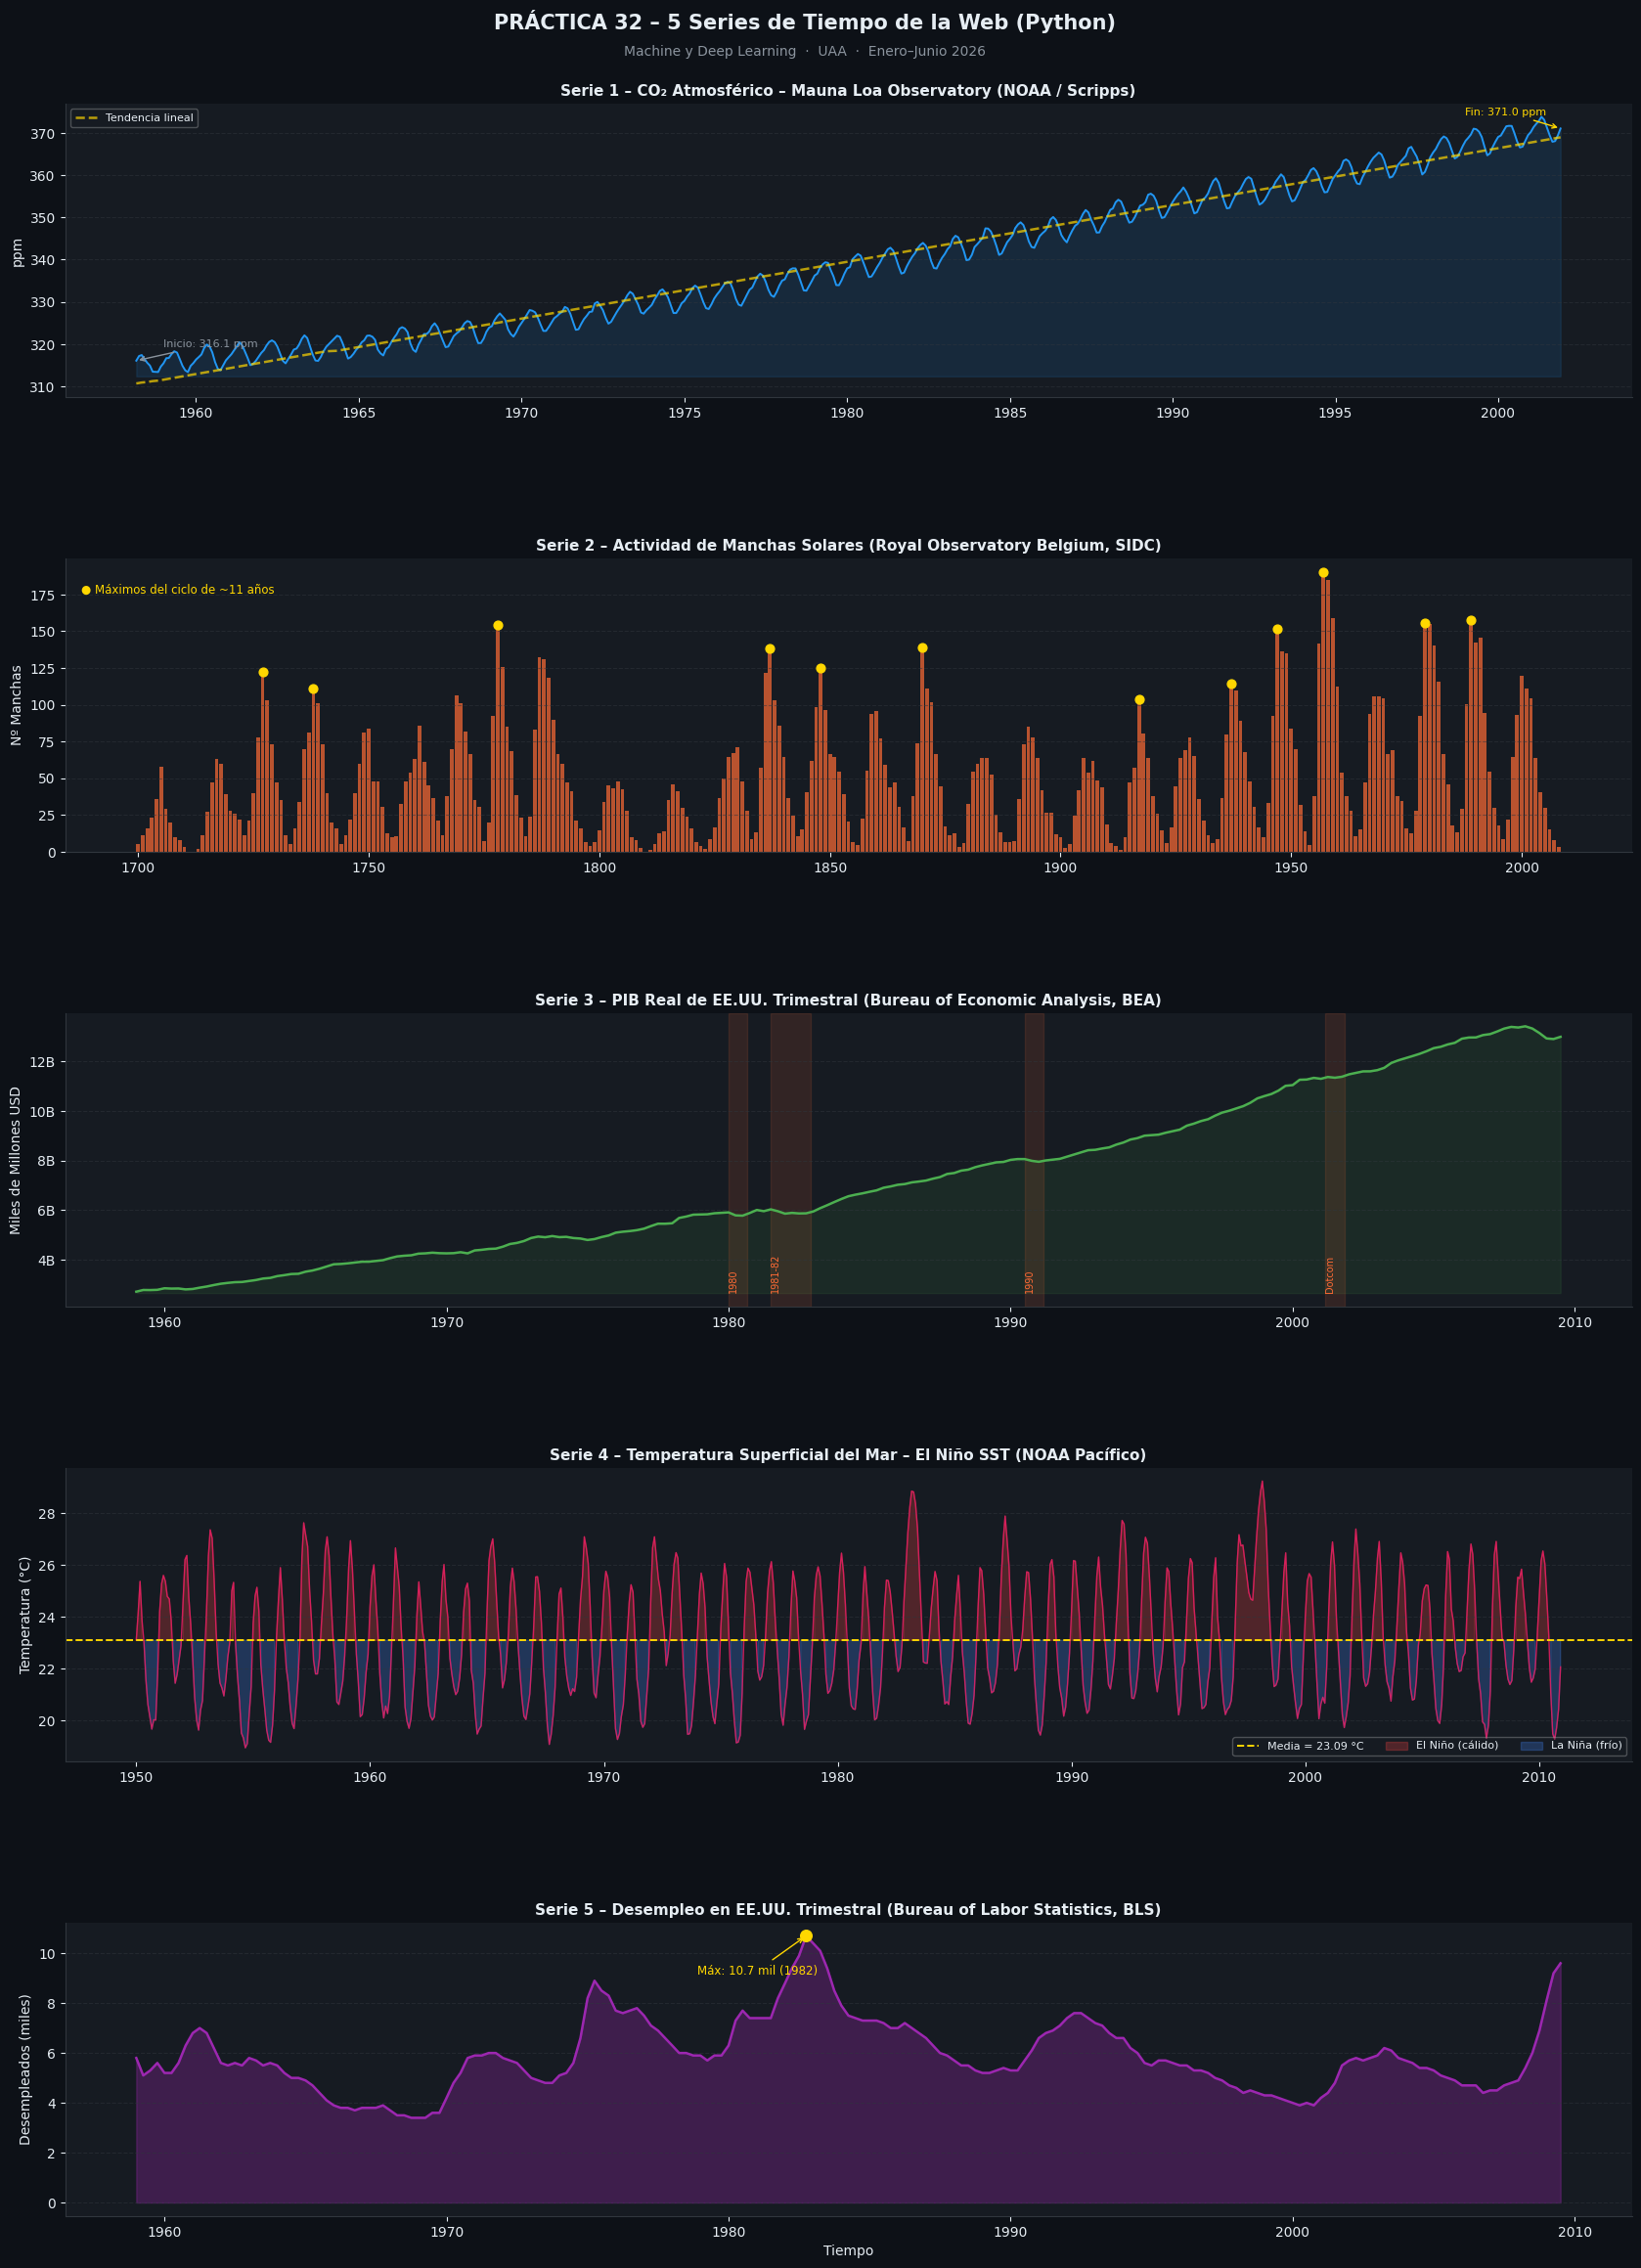

Gráfica conjunta generada ✓


In [5]:
fig = plt.figure(figsize=(18, 24))
fig.patch.set_facecolor(BG_DARK)
fig.text(0.5, 0.98,
         'PRÁCTICA 32 – 5 Series de Tiempo de la Web (Python)',
         ha='center', va='top', fontsize=15, fontweight='bold', color=TEXT_CLR)
fig.text(0.5, 0.965,
         'Machine y Deep Learning  ·  UAA  ·  Enero–Junio 2026',
         ha='center', va='top', fontsize=10, color='#8B949E')

gs = gridspec.GridSpec(5, 1, figure=fig, hspace=0.55,
                       top=0.94, bottom=0.04, left=0.08, right=0.97)

# ── 1. CO2 Atmosférico ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.plot(co2_data.index, co2_data['co2'], color=COLORS[0], lw=1.4)
ax1.fill_between(co2_data.index, co2_data['co2'],
                 co2_data['co2'].min()-1, color=COLORS[0], alpha=0.12)
z = np.polyfit(np.arange(len(co2_data)), co2_data['co2'], 1)
ax1.plot(co2_data.index, np.poly1d(z)(np.arange(len(co2_data))),
         '--', color='#FFD700', lw=1.8, alpha=0.7, label='Tendencia lineal')
ax1.annotate(f"Inicio: {co2_data['co2'].iloc[0]:.1f} ppm",
             xy=(co2_data.index[0], co2_data['co2'].iloc[0]),
             xytext=(20, 10), textcoords='offset points',
             color='#8B949E', fontsize=8,
             arrowprops=dict(arrowstyle='->', color='#8B949E', lw=1))
ax1.annotate(f"Fin: {co2_data['co2'].iloc[-1]:.1f} ppm",
             xy=(co2_data.index[-1], co2_data['co2'].iloc[-1]),
             xytext=(-70, 10), textcoords='offset points',
             color='#FFD700', fontsize=8,
             arrowprops=dict(arrowstyle='->', color='#FFD700', lw=1))
ax1.set_title('Serie 1 – CO₂ Atmosférico – Mauna Loa Observatory (NOAA / Scripps)',
              fontsize=11, fontweight='bold')
ax1.set_ylabel('ppm'); ax1.grid(True, axis='y', ls='--')
ax1.legend(fontsize=8, loc='upper left', framealpha=0.3)

# ── 2. Manchas Solares ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.bar(sun.index, sun['SUNACTIVITY'], color=COLORS[1], alpha=0.7, width=0.8)
# Resaltar ciclos (~11 años): marcar máximos
for i in range(10, len(sun)-10):
    ventana = sun['SUNACTIVITY'].iloc[i-10:i+10]
    if sun['SUNACTIVITY'].iloc[i] == ventana.max() and sun['SUNACTIVITY'].iloc[i] > 100:
        ax2.scatter(sun.index[i], sun['SUNACTIVITY'].iloc[i],
                    color='#FFD700', s=40, zorder=5)
ax2.set_title('Serie 2 – Actividad de Manchas Solares (Royal Observatory Belgium, SIDC)',
              fontsize=11, fontweight='bold')
ax2.set_ylabel('Nº Manchas'); ax2.grid(True, axis='y', ls='--')
ax2.text(0.01, 0.88, '● Máximos del ciclo de ~11 años',
         transform=ax2.transAxes, fontsize=8.5, color='#FFD700')

# ── 3. PIB Real EE.UU. ──────────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
ax3.plot(pib.index, pib['PIB_real_MMUSD'], color=COLORS[2], lw=1.8)
ax3.fill_between(pib.index, pib['PIB_real_MMUSD'],
                 pib['PIB_real_MMUSD'].min()*0.98, color=COLORS[2], alpha=0.10)
for ini, fin, label in [
    ('1980-01-01','1980-09-01','1980'),
    ('1981-07-01','1982-12-01','1981-82'),
    ('1990-07-01','1991-03-01','1990'),
    ('2001-03-01','2001-11-01','Dotcom')]:
    ax3.axvspan(pd.Timestamp(ini), pd.Timestamp(fin), color='#FF6B35', alpha=0.12)
    ax3.text(pd.Timestamp(ini), pib['PIB_real_MMUSD'].min()*1.01, label,
             fontsize=7, color='#FF6B35', rotation=90)
ax3.set_title('Serie 3 – PIB Real de EE.UU. Trimestral (Bureau of Economic Analysis, BEA)',
              fontsize=11, fontweight='bold')
ax3.set_ylabel('Miles de Millones USD')
ax3.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}B'))
ax3.grid(True, axis='y', ls='--')

# ── 4. El Niño SST ──────────────────────────────────────────────
ax4 = fig.add_subplot(gs[3])
media_nino = nino_ts.mean()
ax4.plot(nino_ts.index, nino_ts, color=COLORS[3], lw=1.0, alpha=0.85)
ax4.axhline(media_nino, color='#FFD700', lw=1.4, ls='--',
            label=f'Media = {media_nino:.2f} °C')
ax4.fill_between(nino_ts.index, nino_ts, media_nino,
                 where=(nino_ts >= media_nino),
                 color='#FF4444', alpha=0.25, label='El Niño (cálido)')
ax4.fill_between(nino_ts.index, nino_ts, media_nino,
                 where=(nino_ts < media_nino),
                 color='#4488FF', alpha=0.25, label='La Niña (frío)')
ax4.set_title('Serie 4 – Temperatura Superficial del Mar – El Niño SST (NOAA Pacífico)',
              fontsize=11, fontweight='bold')
ax4.set_ylabel('Temperatura (°C)')
ax4.legend(fontsize=8, loc='lower right', framealpha=0.3, ncol=3)
ax4.grid(True, axis='y', ls='--')

# ── 5. Desempleo EE.UU. ─────────────────────────────────────────
ax5 = fig.add_subplot(gs[4])
ax5.fill_between(unemp.index, unemp['Desempleados_miles'], 0,
                 color=COLORS[4], alpha=0.30)
ax5.plot(unemp.index, unemp['Desempleados_miles'], color=COLORS[4], lw=1.8)
idx_max = unemp['Desempleados_miles'].idxmax()
val_max = unemp['Desempleados_miles'].max()
ax5.scatter([idx_max], [val_max], color='#FFD700', s=70, zorder=5)
ax5.annotate(f'Máx: {val_max:.1f} mil ({idx_max.year})',
             xy=(idx_max, val_max), xytext=(-80, -28),
             textcoords='offset points', color='#FFD700', fontsize=8.5,
             arrowprops=dict(arrowstyle='->', color='#FFD700', lw=1))
ax5.set_title('Serie 5 – Desempleo en EE.UU. Trimestral (Bureau of Labor Statistics, BLS)',
              fontsize=11, fontweight='bold')
ax5.set_ylabel('Desempleados (miles)')
ax5.set_xlabel('Tiempo')
ax5.grid(True, axis='y', ls='--')

plt.savefig('Practica_32_Conjunta.png', dpi=130,
            bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print('Gráfica conjunta generada ✓')

## Paso 6: Gráficas individuales con estadísticas por serie

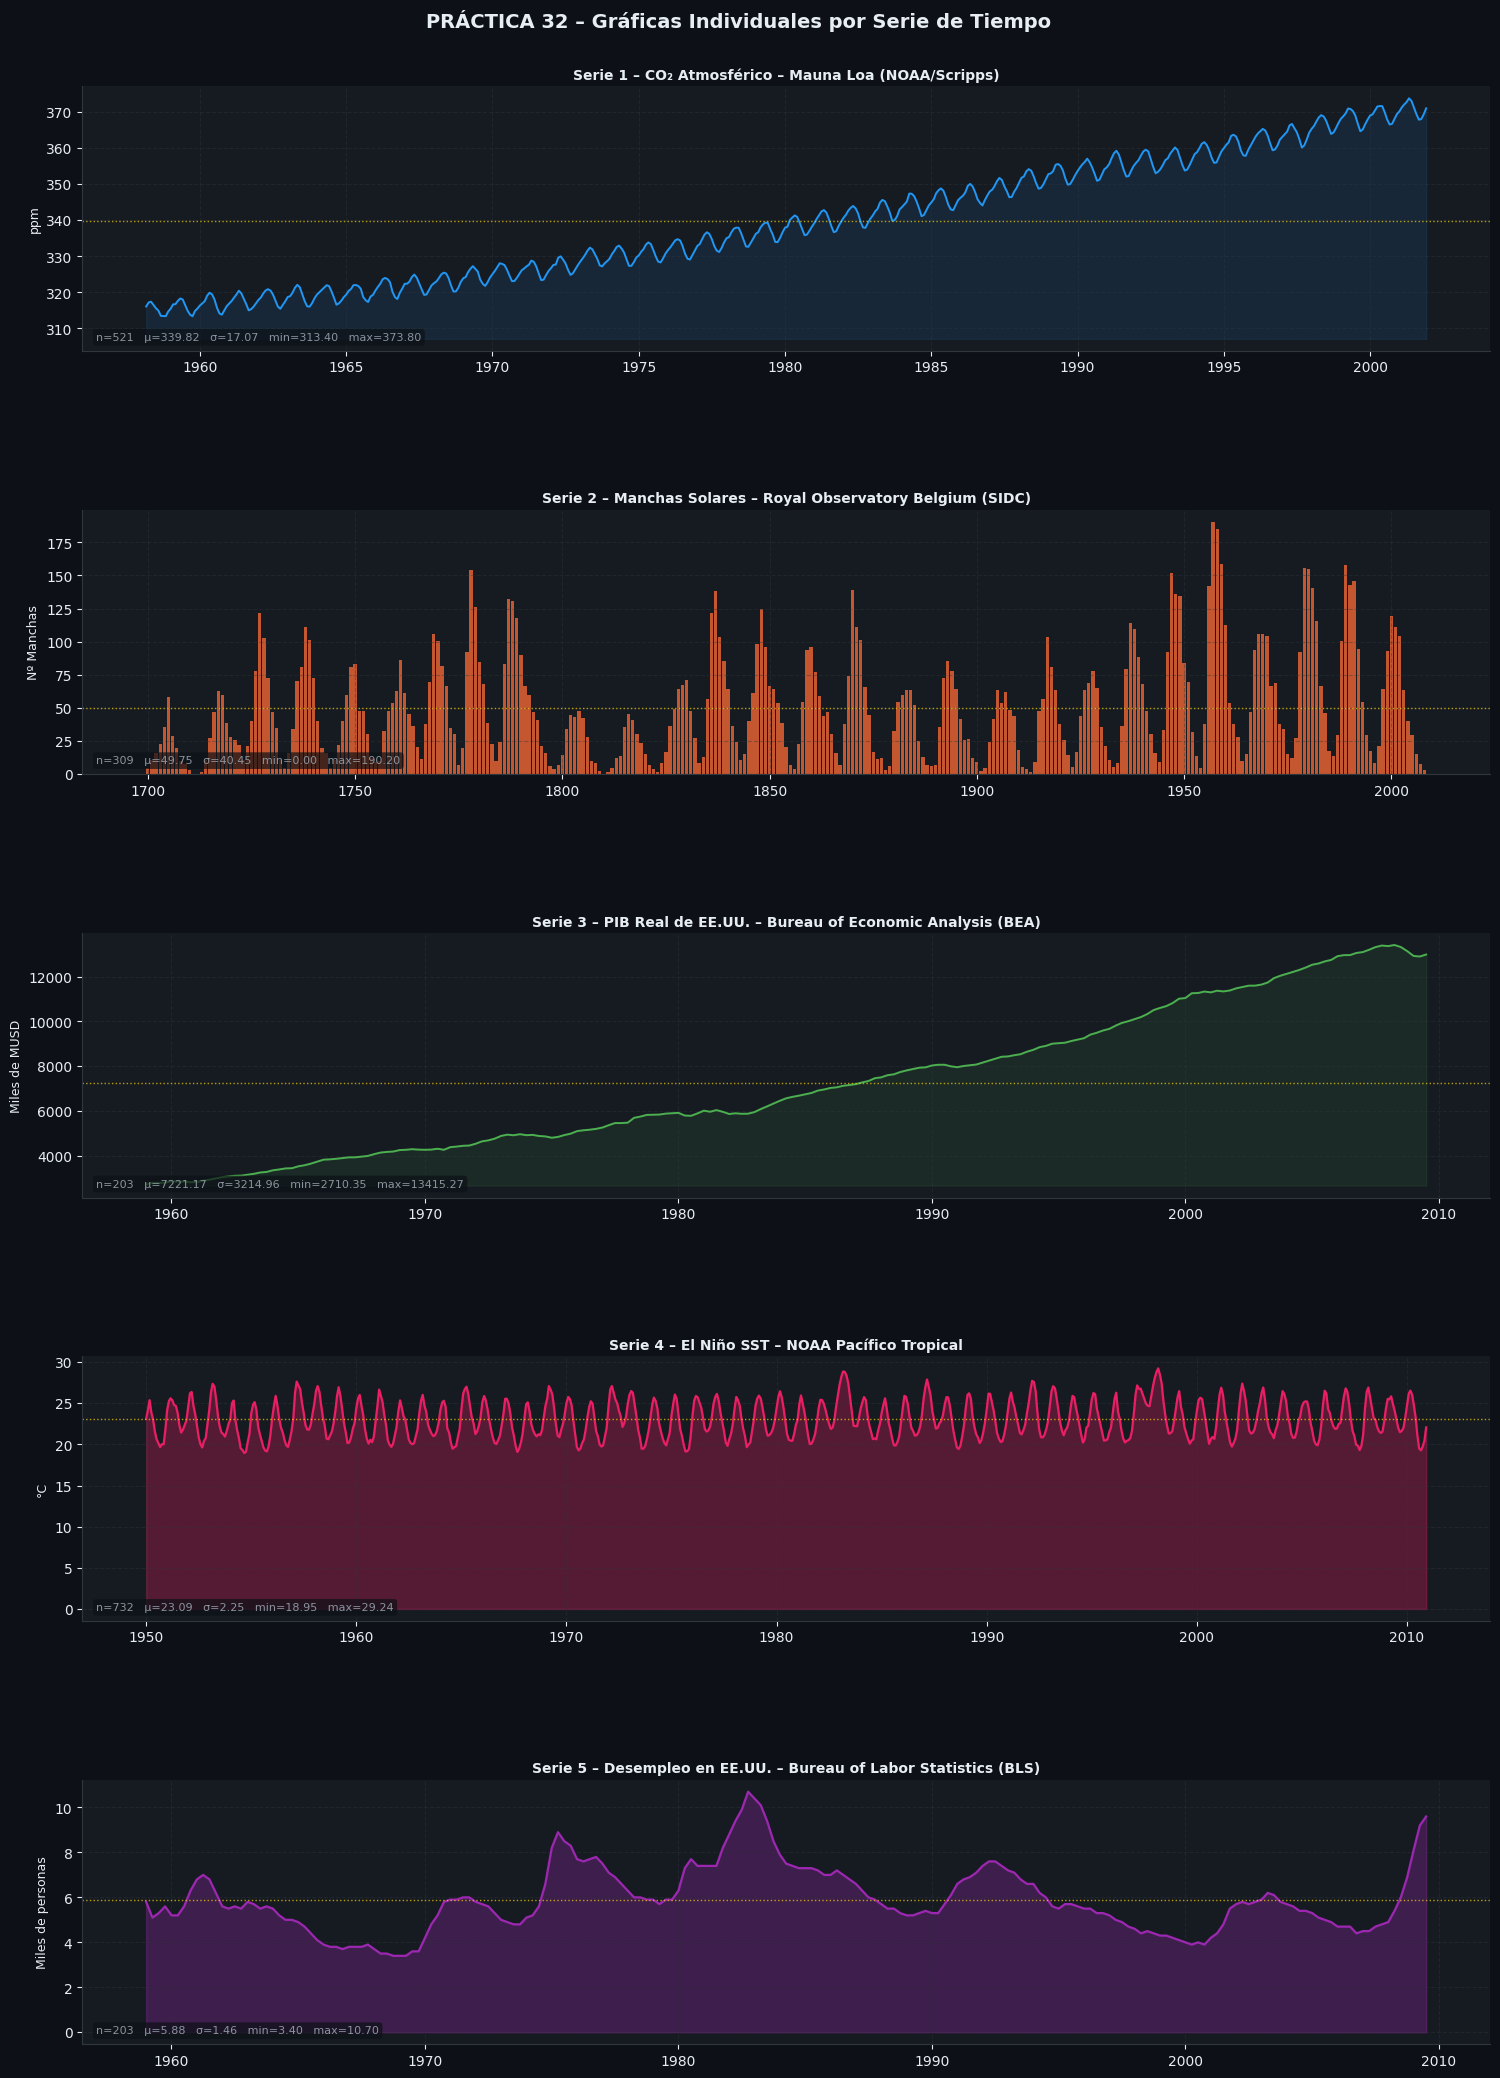

Gráficas individuales generadas ✓


In [6]:
fig2, axes = plt.subplots(5, 1, figsize=(16, 22))
fig2.patch.set_facecolor(BG_DARK)
fig2.subplots_adjust(hspace=0.60, top=0.94, bottom=0.05,
                     left=0.09, right=0.97)
fig2.text(0.5, 0.975,
          'PRÁCTICA 32 – Gráficas Individuales por Serie de Tiempo',
          ha='center', va='top', fontsize=14,
          fontweight='bold', color=TEXT_CLR)

series_info = [
    (co2_data['co2'],
     'Serie 1 – CO₂ Atmosférico – Mauna Loa (NOAA/Scripps)',
     'ppm', COLORS[0], 'line'),
    (sun['SUNACTIVITY'],
     'Serie 2 – Manchas Solares – Royal Observatory Belgium (SIDC)',
     'Nº Manchas', COLORS[1], 'bar'),
    (pib['PIB_real_MMUSD'],
     'Serie 3 – PIB Real de EE.UU. – Bureau of Economic Analysis (BEA)',
     'Miles de MUSD', COLORS[2], 'line'),
    (nino_ts,
     'Serie 4 – El Niño SST – NOAA Pacífico Tropical',
     '°C', COLORS[3], 'fill'),
    (unemp['Desempleados_miles'],
     'Serie 5 – Desempleo en EE.UU. – Bureau of Labor Statistics (BLS)',
     'Miles de personas', COLORS[4], 'fill'),
]

for ax, (serie, titulo, ylabel, color, tipo) in zip(axes, series_info):
    ax.set_facecolor(BG_PANEL)
    for sp in ['top', 'right']:   ax.spines[sp].set_visible(False)
    for sp in ['left', 'bottom']: ax.spines[sp].set_color(GRID_CLR)
    ax.tick_params(colors=TEXT_CLR)
    ax.grid(True, linestyle='--', alpha=0.4, color=GRID_CLR)

    if tipo == 'bar':
        ax.bar(serie.index, serie.values,
               color=color, alpha=0.75, width=0.8)
    elif tipo == 'fill':
        ax.fill_between(serie.index, serie.values, 0,
                        color=color, alpha=0.30)
        ax.plot(serie.index, serie.values, color=color, lw=1.6)
    else:
        ax.plot(serie.index, serie.values, color=color, lw=1.4)
        ax.fill_between(serie.index, serie.values,
                        serie.min() * 0.98, color=color, alpha=0.10)

    mu = serie.mean()
    ax.axhline(mu, color='#FFD700', lw=1.0, ls=':', alpha=0.7)
    stats = (f'n={len(serie)}   μ={mu:.2f}   '
             f'σ={serie.std():.2f}   '
             f'min={serie.min():.2f}   max={serie.max():.2f}')
    ax.text(0.01, 0.04, stats, transform=ax.transAxes,
            fontsize=8, color='#8B949E',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor=BG_DARK, alpha=0.7, edgecolor='none'))
    ax.set_title(titulo, fontsize=10, fontweight='bold',
                 color=TEXT_CLR, pad=5)
    ax.set_ylabel(ylabel, fontsize=9, color=TEXT_CLR)

plt.savefig('Practica_32_Individuales.png', dpi=130,
            bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print('Gráficas individuales generadas ✓')

## Conclusiones

A partir del análisis y graficación de las 5 series de tiempo obtenidas de fuentes reales:

1. **CO₂ Atmosférico (NOAA/Scripps):** Presenta una clara **tendencia lineal ascendente** desde 1958 (~313 ppm → ~374 ppm). El patrón estacional en zigzag refleja el ciclo de la vegetación en el hemisferio norte.

2. **Manchas Solares (SIDC):** Ejemplo clásico de **serie periódica** con el ciclo de Schwabe de ~11 años, observable desde el año 1700. No hay tendencia; solo estacionalidad de largo período.

3. **PIB Real EE.UU. (BEA):** Serie **no estacionaria con tendencia creciente**. Las caídas visibles corresponden a recesiones (1980, 1981-82, 1990, Dotcom 2001). Requeriría diferenciación para modelarse con ARIMA.

4. **El Niño SST (NOAA):** Temperatura oscilante del Pacífico sin tendencia clara. Los picos positivos son eventos **El Niño** (calentamiento) y los negativos **La Niña** (enfriamiento).

5. **Desempleo EE.UU. (BLS):** Sigue ciclos económicos con picos en recesiones, inversamente correlacionada con el PIB. Serie no estacionaria con componente cíclico irregular.

---

## Referencias

- NOAA Earth System Research Laboratory. CO2 dataset via `statsmodels.datasets.co2`
- Royal Observatory of Belgium – SIDC. Sunspot data via `statsmodels.datasets.sunspots`
- NOAA Pacific Marine Environmental Laboratory. El Niño SST via `statsmodels.datasets.elnino`
- Bureau of Economic Analysis / Bureau of Labor Statistics. Macroeconomic data via `statsmodels.datasets.macrodata`
- Seabold, S., & Perktold, J. (2010). *Statsmodels: Econometric and statistical modeling with python.* Proceedings of the 9th Python in Science Conference.